# Simple ML Model vs Large Pretrained NLP Model

In [13]:
!pip install -U transformers

## Local Inference on GPU 
Model page: https://huggingface.co/kota24/distilbert-base-uncased-finetuned-sst-2-english-finetuned-fake-job-posting

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/kota24/distilbert-base-uncased-finetuned-sst-2-english-finetuned-fake-job-posting)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [14]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-classification", model="kota24/distilbert-base-uncased-finetuned-sst-2-english-finetuned-fake-job-posting")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [15]:
import pandas as pd
df=pd.read_excel("/kaggle/input/datasets/adityammantri/trial-1/processed_labeled_dataset_without_encoding.xlsx")
print(df.head())
print(df.tail())

# Verify the column headers to make sure they match your text and label names
print("Dataset Columns:", df.columns.tolist())

                                   job_title  location  industry  \
0                        mental health nurse      4688       649   
1                  conference centre manager      1524       512   
2                              engineer land      1520       649   
3                     forestwoodland manager      1899       435   
4  production designer theatretelevisionfilm       431      1078   

   salary_range                                company_profile  \
0  55016-100476              rivera and sons  established 2022   
1   53438-93138     davidson jones and gomez  established 2003   
2  45584-105229                    allen ltd  established 1998   
3  66188-139621                   forbes ltd  established 1990   
4  32183-115012  jennings martin and sanchez  established 1975   

                                            job_desc  \
0  arm drive court sure vote earn 5000week immedi...   
1  government whom its bed go tax tree black earn...   
2  i member discuss follow

In [16]:
print(df.info())
print(df.isnull().sum())
df = df.dropna(subset=["fraudulent"])
print(df.shape)
df = df.drop(columns=["salary_range"])
df["company_profile"] = df["company_profile"].fillna("")
df["job_desc"] = df["job_desc"].fillna("")
df["skills_desc"] = df["skills_desc"].fillna("")
df["employment_type"] = df["employment_type"].fillna("Unknown")
df["job_title"] = df["job_title"].fillna("Unknown")
print(df.isnull().sum())
df["fraudulent"] = df["fraudulent"].astype(int)
df["fraudulent"].value_counts()
df["fraudulent"].value_counts(normalize=True) * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54391 entries, 0 to 54390
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_title        54389 non-null  object 
 1   location         54391 non-null  int64  
 2   industry         54391 non-null  int64  
 3   salary_range     17123 non-null  object 
 4   company_profile  45992 non-null  object 
 5   job_desc         50871 non-null  object 
 6   skills_desc      41522 non-null  object 
 7   employment_type  38823 non-null  object 
 8   fraudulent       44045 non-null  float64
 9   text             54391 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 4.1+ MB
None
job_title              2
location               0
industry               0
salary_range       37268
company_profile     8399
job_desc            3520
skills_desc        12869
employment_type    15568
fraudulent         10346
text                   0
dtype: int64
(44045, 1

fraudulent
0    71.567715
1    28.432285
Name: proportion, dtype: float64

In [17]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_top_words(text_series, n=20):
    words = " ".join(text_series).split()

    words = [
        word for word in words
        if word.isalpha()
        and len(word) > 1          # Remove single letters
        and word not in ENGLISH_STOP_WORDS
    ]

    return Counter(words).most_common(n)

In [18]:
df["text"] = (
    df["text"]
    .str.replace("ã", " ", regex=False)
    .str.replace("â", " ", regex=False)
    .str.replace("€", " ", regex=False)
)
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

In [19]:
import re

df["text"] = df["text"].str.lower()

df["text"] = df["text"].apply(lambda x: re.sub(r"[^a-z\s]", " ", x))

df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

In [20]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")
nltk.download("omw-1.4")
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


In [21]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove non-letter characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stop words and lemmatize
    words = [
        lemmatizer.lemmatize(word) 
        for word in words
        if word not in ENGLISH_STOP_WORDS
    ]

    return " ".join(words)

# Apply preprocessing to create a new column
df["clean_text"] = df["text"].apply(preprocess_text)

In [22]:
def preprocess_text(text):
    text = text.lower()

    # Expand common contractions BEFORE removing punctuation
    text = text.replace("'s", "")
    text = text.replace("'re", " are")
    text = text.replace("'ve", " have")
    text = text.replace("'ll", " will")
    text = text.replace("'d", " would")
    text = text.replace("n't", " not")

    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    # Remove stop words and unwanted short tokens
    remove_words = {
        "s", "t", "re", "ve", "ll", "d", "m",
        "uk", "usa"
    }

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in ENGLISH_STOP_WORDS
        and word not in remove_words
        and len(word) > 1
    ]

    return " ".join(words)

In [23]:
df["clean_text"] = df["text"].apply(preprocess_text)
df_model = df.drop_duplicates(subset=["clean_text"]).copy()

print(df.shape)
print(df_model.shape)

(44045, 10)
(26003, 10)


In [24]:
print(df.shape)
df.dtypes
df.describe(include="all")

(44045, 10)


,job_title,location,industry,company_profile,job_desc,skills_desc,employment_type,fraudulent,text,clean_text
count,44045,44045.000000,44045.000000,44045,44045,44045,44045,44045.000000,44045,44045
unique,11253,NaN,NaN,11710,24918,13177,12,NaN,26021,26003
top,customer service associate,NaN,NaN,,play with kids get paid for itã love travel jo...,,Full-time,NaN,english teacher abroad we help teachers get sa...,english teacher abroad help teacher safe amp s...
freq,424,NaN,NaN,6947,379,4605,23564,NaN,401,401
mean,NaN,2180.054808,822.538858,NaN,NaN,NaN,NaN,0.284323,NaN,NaN
std,NaN,1331.881690,419.193500,NaN,NaN,NaN,NaN,0.451096,NaN,NaN
min,NaN,0.000000,2.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,1166.000000,512.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,NaN,1954.000000,704.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,NaN,3223.000000,1263.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


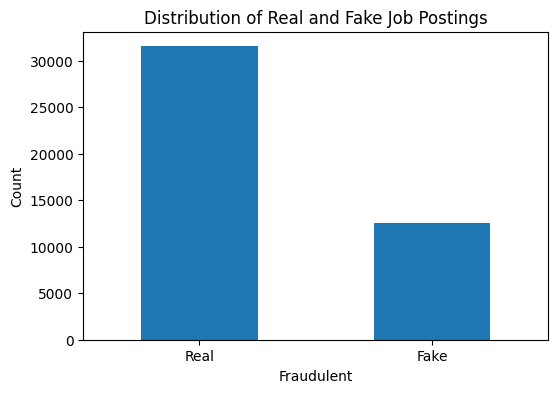

In [25]:
import matplotlib.pyplot as plt

df["fraudulent"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Real and Fake Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.xticks([0,1],["Real","Fake"],rotation=0)

plt.show()

In [26]:
print(df["employment_type"].unique())
print(df["employment_type"].value_counts())
df["employment_type"] = (
    df["employment_type"]
    .str.strip()          
    .str.title()          
)
df["employment_type"] = df["employment_type"].replace({
    "Full-Time": "Full Time",
    "Part-Time": "Part Time",
    "Fulltime": "Full Time",
    "Parttime": "Part Time",
    "Internship & Graduate": "Internship"
})
print(df["employment_type"].unique())

['Internship' 'Part-Time' 'Full-Time' 'Temporary' 'Contract' 'Other'
 'Full-time' 'Unknown' 'Part-time' 'Full Time' 'Internship & Graduate'
 'Part Time']
employment_type
Full-time                23564
Unknown                   5222
Contract                  4501
Temporary                 2486
Part-Time                 2039
Internship                1982
Full-Time                 1977
Part-time                 1667
Other                      463
Full Time                  140
Part Time                    3
Internship & Graduate        1
Name: count, dtype: int64
['Internship' 'Part Time' 'Full Time' 'Temporary' 'Contract' 'Other'
 'Unknown']


In [27]:
real_jobs = df[df["fraudulent"] == 0]["text"]
fake_jobs = df[df["fraudulent"] == 1]["text"]
real_jobs = df[df["fraudulent"] == 0]["text"]
fake_jobs = df[df["fraudulent"] == 1]["text"]

In [28]:
from collections import Counter

real_counter = Counter(" ".join(real_jobs).split())
fake_counter = Counter(" ".join(fake_jobs).split())
fake_unique = {}

for word, count in fake_counter.items():
    diff = count - real_counter.get(word, 0)
    if diff > 0:
        fake_unique[word] = diff

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

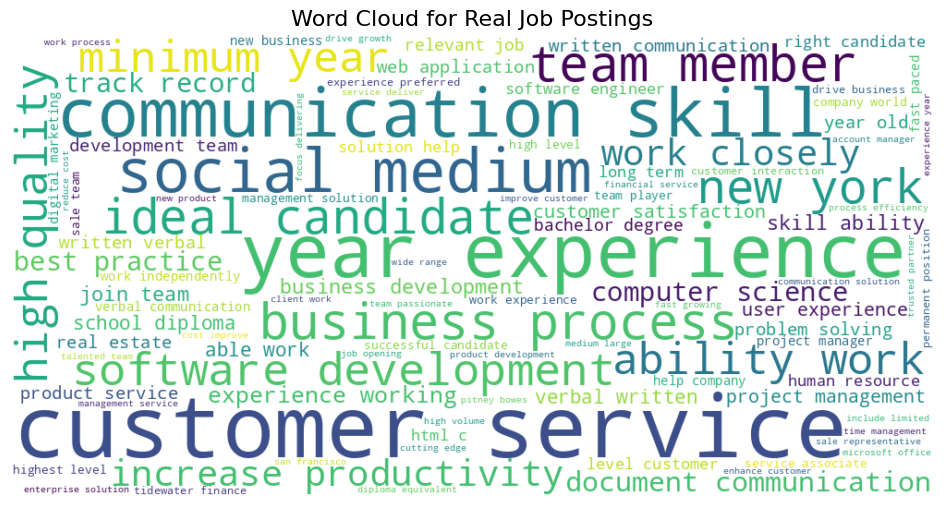

In [30]:
real_text = " ".join(df[df["fraudulent"] == 0]["clean_text"])

wordcloud_real = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(real_text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud_real, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Real Job Postings", fontsize=16)
plt.show()

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=20
)

X_real = vectorizer.fit_transform(df[df["fraudulent"] == 0]["clean_text"])

real_bigram_counts = X_real.toarray().sum(axis=0)

real_bigrams = sorted(
    zip(vectorizer.get_feature_names_out(), real_bigram_counts),
    key=lambda x: x[1],
    reverse=True
)

real_bigrams

[('customer service', np.int64(11196)),
 ('year experience', np.int64(7976)),
 ('communication skill', np.int64(6525)),
 ('social medium', np.int64(5212)),
 ('business process', np.int64(3338)),
 ('team member', np.int64(3303)),
 ('ideal candidate', np.int64(3049)),
 ('new york', np.int64(2880)),
 ('software development', np.int64(2690)),
 ('high quality', np.int64(2613)),
 ('minimum year', np.int64(2582)),
 ('ability work', np.int64(2553)),
 ('increase productivity', np.int64(2537)),
 ('work closely', np.int64(2486)),
 ('document communication', np.int64(2484)),
 ('computer science', np.int64(2385)),
 ('track record', np.int64(2362)),
 ('best practice', np.int64(2356)),
 ('experience working', np.int64(2267)),
 ('business development', np.int64(2233))]

In [32]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=20
)

X_fake = vectorizer.fit_transform(df[df["fraudulent"] == 1]["clean_text"])

fake_bigram_counts = X_fake.toarray().sum(axis=0)

fake_bigrams = sorted(
    zip(vectorizer.get_feature_names_out(), fake_bigram_counts),
    key=lambda x: x[1],
    reverse=True
)

fake_bigrams

[('earn week', np.int64(10072)),
 ('flexible hour', np.int64(10018)),
 ('basic knowledge', np.int64(10011)),
 ('degree required', np.int64(10008)),
 ('hiring contact', np.int64(10000)),
 ('immediate hiring', np.int64(10000)),
 ('required flexible', np.int64(10000)),
 ('week immediate', np.int64(10000)),
 ('knowledge degree', np.int64(2171)),
 ('customer service', np.int64(894)),
 ('data entry', np.int64(724)),
 ('plc established', np.int64(596)),
 ('llc established', np.int64(560)),
 ('son established', np.int64(553)),
 ('communication skill', np.int64(528)),
 ('group established', np.int64(524)),
 ('year experience', np.int64(484)),
 ('work home', np.int64(474)),
 ('hotmailcom basic', np.int64(438)),
 ('yahoocom basic', np.int64(437))]

In [33]:
X = df_model["clean_text"]
y = df_model["fraudulent"]

print(X.head())
print(y.head())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

0    mental health nurse rivera son established arm...
1    conference centre manager davidson jones gomez...
2    engineer land allen established member discus ...
3    forestwoodland manager forbes established hous...
4    production designer theatretelevisionfilm jenn...
Name: clean_text, dtype: object
0    1
1    1
2    1
3    1
4    1
Name: fraudulent, dtype: int64
Training samples: 20802
Testing samples: 5201


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=5,
    max_df=0.90
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(20802, 5000)
(5201, 5000)


In [35]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['aa' 'ab' 'abc' 'abc supply' 'ability' 'ability adapt' 'ability build'
 'ability communicate' 'ability effectively' 'ability learn'
 'ability manage' 'ability multitask' 'ability prioritize'
 'ability required' 'ability work' 'able' 'able communicate'
 'able demonstrate' 'able multitask' 'able perform' 'able work' 'abroad'
 'absolutely' 'ac' 'academic' 'accelerate' 'accept' 'acceptable'
 'acceptance' 'access']


In [36]:
import pandas as pd

doc = pd.DataFrame({
    "Term": feature_names,
    "Weight": X_train_tfidf[0].toarray().flatten()
})

doc = doc[doc["Weight"] > 0]

doc.sort_values("Weight", ascending=False).head(20)

,Term,Weight
4321,support,0.378812
3523,providing,0.229739
4194,sql,0.205101
1028,customer,0.163622
4326,support service,0.149743
4639,unix,0.143583
4713,valued,0.140935
682,client base,0.138694
4434,technical skill,0.137580
4716,varied,0.137444


In [37]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_tfidf, y_train)
y_pred = lr_model.predict(X_test_tfidf)
y_prob = lr_model.predict_proba(X_test_tfidf)[:,1]
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9769
Precision: 0.9980
Recall   : 0.9462
F1 Score : 0.9714


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3045
           1       1.00      0.95      0.97      2156

    accuracy                           0.98      5201
   macro avg       0.98      0.97      0.98      5201
weighted avg       0.98      0.98      0.98      5201



In [39]:
# 1. Define the identical scam sample strings
sample_title = "Data Entry Associate - Work From Home"
sample_desc = "Earn $5000 a week processing basic online form sheets. No prior experience required. Immediate start today after short wire app interview!"
sample_reqs = "Must have a laptop and an open bank account to receive immediate sign-on bonus transfers."

# Combine the text using the exact same format used in your training data
raw_sample_text = f"{sample_title} {sample_desc} {sample_reqs}"

# 2. Transform the text using your existing fitted TfidfVectorizer instance
# Ensure your vectorizer variable name matches ('tfidf')
sample_tfidf = tfidf.transform([raw_sample_text])

# 3. Execute inference using your trained Logistic Regression model
# Ensure your model variable name matches ('lr_model')
pred_class = lr_model.predict(sample_tfidf)[0]
pred_proba = lr_model.predict_proba(sample_tfidf)[0]

# 4. Print the performance comparison results
labels_map = {0: "Real Job Posting", 1: "FRAUDULENT/FAKE Job Posting"}

print("=== Logistic Regression Inference Results ===")
print(f"Predicted Class: {labels_map[pred_class]}")
print(f"Confidence - Real: {pred_proba[0]*100:.2f}% | Fake: {pred_proba[1]*100:.2f}%")


=== Logistic Regression Inference Results ===
Predicted Class: FRAUDULENT/FAKE Job Posting
Confidence - Real: 14.27% | Fake: 85.73%


# Distil Bert

In [40]:
import torch
import numpy as np
import pandas as pd
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments
)
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report
)

# 1. Hardware acceleration check (Crucial for Transformers)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Fine-tuning on device: {device}")

# 2. Instantiate original tokenizer and model
model_name = "kota24/distilbert-base-uncased-finetuned-sst-2-english-finetuned-fake-job-posting"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

# 3. Formulate custom PyTorch wrapper dataset for Trainer compatibility
class JobPostingDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.encodings = tokenizer(
            list(texts), 
            truncation=True, 
            padding="max_length", 
            max_length=max_length, 
            return_tensors="pt"
        )
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# Build training and validation sets from your clean variables
train_dataset = JobPostingDataset(X_train, y_train, tokenizer)
test_dataset = JobPostingDataset(X_test, y_test, tokenizer)

# 4. Set structural evaluation tracking function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0)
    }



Fine-tuning on device: cuda


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

# Reduce Trainable Parameters 


In [41]:
import torch
from transformers import AutoModelForSequenceClassification

# 1. Load the original base model
model_name = "kota24/distilbert-base-uncased-finetuned-sst-2-english-finetuned-fake-job-posting"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# =====================================================================
# 2. FREEZE ALL TRANSFOMER LAYERS
# =====================================================================
# Loop through every single weight parameter inside the network
for name, param in model.named_parameters():
    # If the parameter belongs to the final classification layers, leave it open
    if "classifier" in name or "pre_classifier" in name:
        param.requires_grad = True
    else:
        # Otherwise, lock the weights so they cannot change during training
        param.requires_grad = False

# =====================================================================
# 3. VERIFY METRIC SCALARS
# =====================================================================
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("=== Parameter Layer Configuration Status ===")
print(f"Total Network Parameters: {total_params:,}")
print(f"Locked (Frozen) Baseline Parameters: {frozen_params:,}")
print(f"Active (Trainable) Head Parameters : {trainable_params:,}")
print(f"Percentage of model being trained  : {(trainable_params / total_params) * 100:.4f}%")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== Parameter Layer Configuration Status ===
Total Network Parameters: 66,955,010
Locked (Frozen) Baseline Parameters: 66,362,880
Active (Trainable) Head Parameters : 592,130
Percentage of model being trained  : 0.8844%


In [42]:
# Calculate total parameters across the entire deep learning network
total_transformer_params = sum(p.numel() for p in model.parameters())
trainable_transformer_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"DistilBERT Total Parameters: {total_transformer_params:,}")
print(f"DistilBERT Trainable Parameters: {trainable_transformer_params:,}")


DistilBERT Total Parameters: 66,955,010
DistilBERT Trainable Parameters: 592,130


In [43]:
from transformers import Trainer, TrainingArguments

# 1. Set up optimized training arguments for layer-frozen models
frozen_training_args = TrainingArguments(
    output_dir="./frozen_results",
    learning_rate=5e-4,                  # Higher learning rate since we are only tuning the classification head
    per_device_train_batch_size=32,       # Increased batch size (16 -> 32) because freezing saves massive VRAM
    per_device_eval_batch_size=32,
    num_train_epochs=1,                  # 2 epochs are plenty for a classification head to converge
    weight_decay=0.01,
    eval_strategy="epoch",               # Evaluates performance metrics at the end of each epoch loop
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    fp16=torch.cuda.is_available()       # Keeps memory footprint tiny using mixed precision tracking
)

# 2. Initialize the high-level Trainer class
frozen_trainer = Trainer(
    model=model,                         # Pass your layer-frozen model instance here
    args=frozen_training_args,
    train_dataset=train_dataset,         # Your clean raw text training dataset
    eval_dataset=test_dataset,           # Your evaluation validation text dataset
    compute_metrics=compute_metrics,     # Custom accuracy/precision/recall evaluation tracking function
)

print("\n--- Initiating Optimized Layer-Frozen Fine-Tuning Loop ---")
frozen_trainer.train()

# =====================================================================
# 3. PRINT POST-TRAINING METRIC PERFORMANCES
# =====================================================================
print("\n--- Frozen Model Performance Evaluation ---")
eval_results = frozen_trainer.evaluate()

print(f"Accuracy : {eval_results['eval_accuracy']:.4f}")
print(f"Precision: {eval_results['eval_precision']:.4f}")
print(f"Recall   : {eval_results['eval_recall']:.4f}")
print(f"F1 Score : {eval_results['eval_f1']:.4f}\n")



--- Initiating Optimized Layer-Frozen Fine-Tuning Loop ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.307461,0.956355,0.951334,0.942950,0.947123


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Frozen Model Performance Evaluation ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,0.307461,1,0.956355,0.951334,0.942950,0.947123


Accuracy : 0.9564
Precision: 0.9513
Recall   : 0.9429
F1 Score : 0.9471



In [44]:
# Save your model weights locally inside Kaggle
model.save_pretrained("./prod_job_classifier")
tokenizer.save_pretrained("./prod_job_classifier")
print("✅ Success: Deployment assets saved to './prod_job_classifier'")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Success: Deployment assets saved to './prod_job_classifier'
